In [ ]:
from cluster_paths import get_cluster_paths
scratch_path, repo_path, backup_path = get_cluster_paths()

%load_ext autoreload
%autoreload 2

import os, h5py
import numpy as np
import matplotlib.pyplot as plt

from msfm.utils import files, parameters, buzzard
from msfm.utils.input_output import read_yaml

from msi.flow_conductor.likelihood_flow import LikelihoodFlow
from msi.utils import flow as flow_utils
from msi.utils import input_output


# v16

In [13]:
# subversion = "default"
# subversion = "no_sc"
subversion = "rot_in_place"

# msfm_conf = files.load_config(f"{repo_path}/multiprobe-simulation-forward-model/configs/v16/default.yaml")
# base_dir = f"{scratch_path}/deep_lss/v16/default/maps"

msfm_conf = files.load_config(f"{repo_path}/multiprobe-simulation-forward-model/configs/v16/{subversion}.yaml")
base_dir = f"{scratch_path}/deep_lss/runs/v16/{subversion}/cls"

In [14]:
probe = "lensing"
params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]

# model_name = "v1"
# n_steps = 500_000

# model_name = "v5_small"
model_name = "v5_diag"
n_steps = 500_000

In [15]:
# probe = "clustering"
# params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4"]

# # model_name = ""
# # n_steps = 500_000

# # model_name = "v3/24Mpc"
# # model_name = "v3/28Mpc"
# # model_name = "v3/32Mpc"
# model_name = "v3/36Mpc"
# n_steps = 500_000

In [16]:
# probe = "2x2pt"
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]

# model_name = "v1"
# n_steps = 300_000

In [17]:
# probe = "combined"
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]

# model_name = "v1"
# n_steps = 300_000

# constants

In [18]:
buzzard_cosmo = buzzard.get_cosmo(msfm_conf, params)
n_params = len(params)

pred_dir = os.path.join(base_dir, probe, model_name)
pred_file = os.path.join(pred_dir, f"preds_{n_steps}.h5")

grid_preds, grid_cosmos, obs_pred_dict, obs_cosmo_dict = input_output.load_network_preds_simple(pred_file)

26-05-15 14:17:03 input_output INF   Loading predictions from /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/lensing/v5_diag/preds_500000.h5 
26-05-15 14:17:03 input_output INF   grid_preds.shape = (200000, 12) 
26-05-15 14:17:03 input_output INF   grid_cosmos.shape = (200000, 6) 
26-05-15 14:17:03 input_output INF   DESy3 with shape (12,) 
26-05-15 14:17:03 input_output INF   bench_fidu_mean with shape (12,) 
26-05-15 14:17:03 input_output INF   bench_fidu_stack with shape (80, 12) 
26-05-15 14:17:03 input_output INF   grid_0 with shape (12,) 
26-05-15 14:17:03 input_output INF   grid_160 with shape (12,) 
26-05-15 14:17:03 input_output INF   grid_240 with shape (12,) 
26-05-15 14:17:03 input_output INF   grid_80 with shape (12,) 


# likelihood Flow $p(x|\theta)$

In [ ]:
# Select a flow config and the label that identifies the checkpoint on disk.
# flow_label must match --flow_label from the submission script ("" for unlabeled runs).
flow_config_path = f"{repo_path}/multiprobe-simulation-inference/configs/flow/default.yaml"
flow_label = "default"   # "default" | "smaller" | "larger" | "dropout" | "lipschitz" | ""

flow_conf = read_yaml(flow_config_path)
prefix = f"{flow_label}_" if flow_label else ""


### loading

In [ ]:
flow = LikelihoodFlow.from_checkpoint(
# flow = LikelihoodFlowEnsemble.from_checkpoint(
    out_dir=pred_dir,
    prefix=prefix,
    suffix=f"_{n_steps}",
)


### training

In [ ]:
# x_dim = grid_preds.shape[-1]
# theta_dim = grid_cosmos.shape[-1]

# embedding_net, transform = flow_utils.build_flow_architecture(x_dim, theta_dim, flow_conf)

# flow = LikelihoodFlow(
#     params,
#     msfm_conf,
#     feature_dim=x_dim,
#     embedding_net=embedding_net,
#     transform=transform,
#     out_dir=pred_dir,
#     prefix=prefix,
#     suffix=f"_{n_steps}",
#     load_existing=False,
# )

# history = flow.fit(
#     x=grid_preds,
#     theta=grid_cosmos,
#     n_epochs=flow_conf.get("training", {}).get("n_epochs", 100),
#     batch_size=flow_conf.get("training", {}).get("batch_size", 10_000),
#     scheduler_type=flow_conf.get("training", {}).get("scheduler_type", "cosine"),
#     save_model=True,
#     run_c2st=True,
# )

# flow.plot_diagnostics(
#     grid_preds_true=grid_preds,
#     grid_cosmos=grid_cosmos,
#     n_cosmos=flow_conf.get("diagnostics", {}).get("n_cosmos", 1000),
# )


# observation

## CosmoGrid

### grid

In [21]:
# obs_dict = {}

# n_examples = 4

# for i_grid in range(n_examples):
#     # unique cosmological parameters
#     i_grid *= msfm_conf["analysis"]["grid"]["n_perms_per_cosmo"] * msfm_conf["analysis"]["n_patches"]

#     obs_label = f"grid_{i_grid}"
#     obs_dict[f"grid_{i_grid}"] = {
#         "pred": grid_preds[i_grid],
#         "cosmo": {str(param): value for param, value in zip(params, obs_cosmo_dict[obs_label])},
#     }


### benchmarks

In [22]:
obs_dict = {}
obs_cosmo = {str(param): value for param, value in zip(params, parameters.get_fiducials(params, msfm_conf))}

obs_labels = ["bench_fidu"]
# obs_labels += ["bench_box", "bench_particle", "bench_redshift"]
# # obs_labels += ["source_clustering_bgs_low", "source_clustering_bgs_high"]
# # obs_labels = ["fidu_bary", "fidu_dmo"]
# # obs_labels += ["ia_shell"]
# obs_labels = ["bench_bsc=rot", "bench_bsc=fit", "bench_bsc=0", "bench_bsc=1"]
# obs_labels = ["bench_bsc=rot"]


for obs_label in obs_labels:
    obs_label += "_mean"
    obs_preds = obs_pred_dict[obs_label]
    
    obs_dict[obs_label] = {
        "pred": obs_preds, 
        "cosmo": obs_cosmo,
    }


## DES Y3

In [23]:
# obs_dict = {}

# obs_label = "DESy3"

# obs_dict[obs_label] = {
#     "pred": obs_pred_dict[obs_label],
#     "cosmo": None,
# }

## Buzzard

In [24]:
# obs_labels = []
# # obs_labels += [f"Buzzard_{i}" for i in [0] + list(range(2, 16))]
# obs_labels += ["Buzzard_mean"]
# # obs_labels += ["Buzzard_stack"]

# for obs_label in obs_labels:
#     obs_preds = all_obs_preds[obs_label]
    
#     obs_dict[obs_label] = {
#         "pred": obs_preds, 
#         "cosmo": obs_cosmo,
#     }

In [25]:
# obs_dict = {}

# # buzzard_indices = list(range(0, 16))
# # buzzard_indices.remove(1)
# buzzard_indices = [0, 2]
# buzzard_stack = []
# for i in buzzard_indices:
#     pred = all_obs_preds[f"Buzzard_{i}"]
#     buzzard_stack.append(pred)
    
#     # obs_dict[f"Buzzard_{i}"] = {
#     #     "pred": pred,
#     #     "cosmo": buzzard_cosmo,
#     # }

# buzzard_stack = np.stack(buzzard_stack, axis=0)

# obs_dict[f"Buzzard_mean"] = {
#     "pred": np.mean(buzzard_stack, axis=0),
#     "cosmo": buzzard_cosmo,
# }

# obs_dict[f"Buzzard_stack"] = {
#     "pred": np.stack(buzzard_stack, axis=0),
#     "cosmo": buzzard_cosmo,
# }

### MCMC and plotting


Starting with mock observation bench_fidu_mean
26-05-15 14:17:06 likelihood_f INF   Sampling the posterior from a single observation 
26-05-15 14:17:06 likelihood_f WAR   wCDM 
26-05-15 14:17:06      mcmc.py INF   Initial values in prior: 46.9% 
26-05-15 14:17:06      mcmc.py INF   Starting the burn in MCMC chain (1000 steps) 


100%|██████████| 1000/1000 [00:31<00:00, 31.69it/s]

26-05-15 14:17:39      mcmc.py INF   Starting the main MCMC chain (1000 steps) 



100%|██████████| 1000/1000 [00:29<00:00, 33.45it/s]

26-05-15 14:18:09      mcmc.py INF   Saved the MCMC chain to /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/lensing/v5_diag/likelihood_flow_None/chain_bench_fidu_mean.npy 



/users/athomsen/dlss/torch_env/lib/python3.12/site-packages/trianglechain/make_subplots.py:130: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  axc.plot(
100%|██████████| 21/21 [00:01<00:00, 14.07it/s]
/users/athomsen/dlss/torch_env/lib/python3.12/site-packages/trianglechain/make_subplots.py:130: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  axc.plot(
100%|██████████| 21/21 [00:00<00:00, 1687.33it/s]


26-05-15 14:18:14  plotting.py INF   Saved the plot to /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/lensing/v5_diag/likelihood_flow_None/contours_bench_fidu_mean.png 


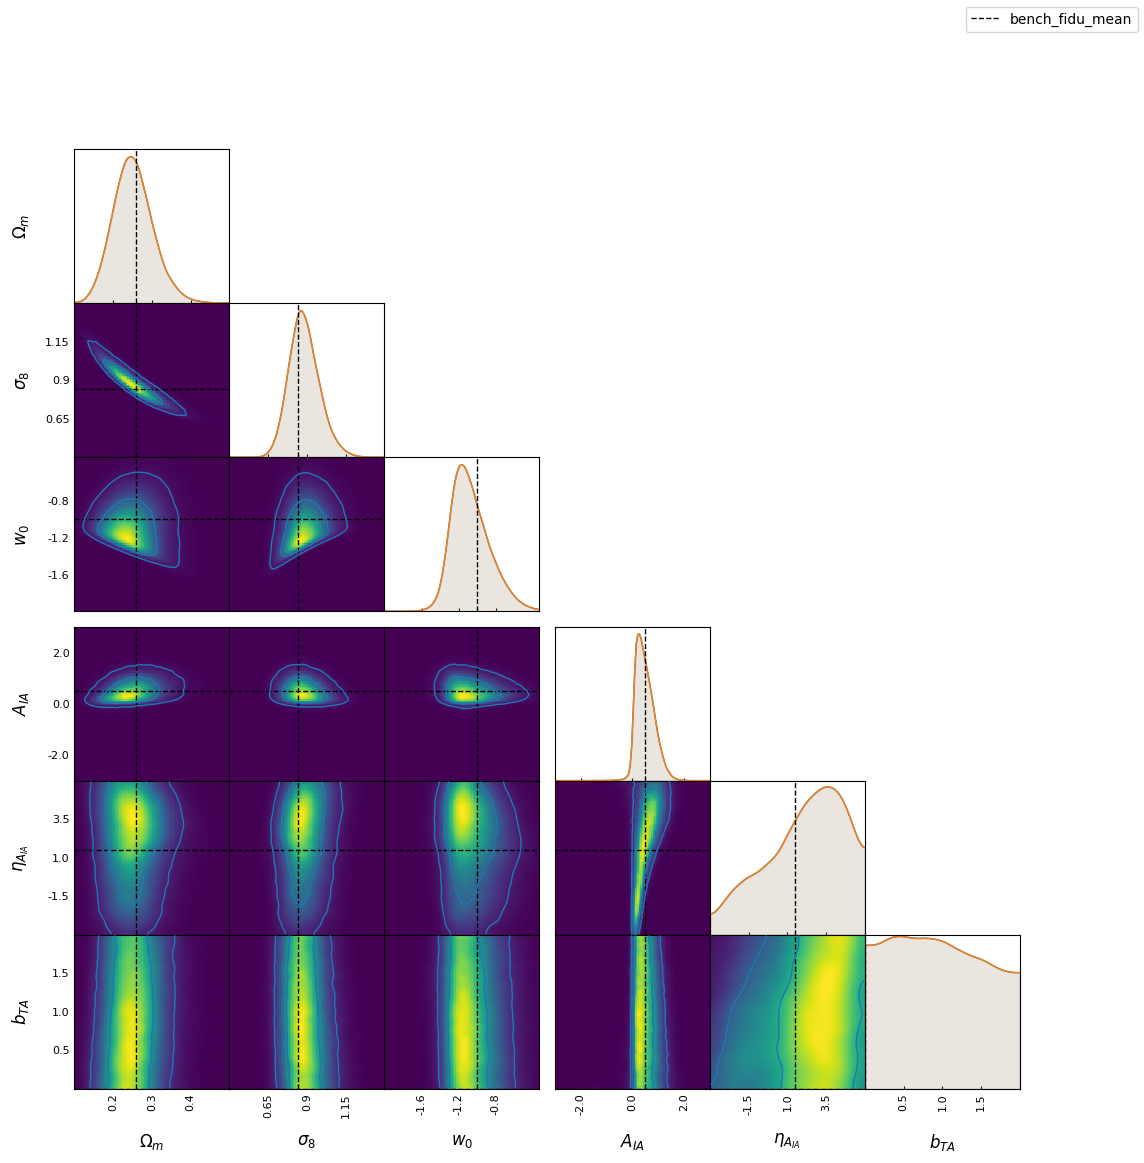

In [26]:
extra_label = ""

for key in obs_dict.keys():
    print(f"\nStarting with mock observation {key}")
    
    posterior_samples = flow.sample_posterior(
        obs_dict[key]["pred"],
        label=key+extra_label,
        n_walkers=1024,
        n_steps=1000,
        n_burnin_steps=1000,
    )

    if not "des" in key.lower():
        flow.plot_contours(
            posterior_samples,
            obs_point=obs_dict[key]["cosmo"],
            obs_label=key,
            label=key+extra_label,
            with_des_chain=False,
            density=True
        )